### Задание 7. 

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [293]:
from Bio import SeqIO
record = SeqIO.read ("/Users/arina.anurieva/Downloads/chr1.fa", "fasta")
seq = str(record.seq)[:100000].upper()

In [294]:
def compute_cpg_ratio(window):
    N = len(window)
    C_counts = (1 if window[0]=="C" else 0)/N
    G_counts = (1 if window[0]=="G" else 0)/N
    CG_counts = 0
    for i in range(1, len(window)):
        C_counts += (1 if window[i]=="C" else 0)/N
        G_counts += (1 if window[i]=="G" else 0)/N
        CG_counts += (1 if window[i-1:i+1]=="CG" else 0)/(N+1)
    R_CG = 0
    if CG_counts != 0:
        R_CG = CG_counts/G_counts/C_counts
    GC_per = (C_counts+G_counts)

    return C_counts, G_counts, CG_counts, R_CG, GC_per

In [295]:
compute_cpg_ratio(seq[300:501])

(0.5373134328358198,
 0.05472636815920397,
 0.029702970297029705,
 1.0101260126012626,
 0.5920398009950237)

In [296]:
window_size = 200
CpG_coords = []
R_CGs, GC_pers = [], []
for i in range(len(seq)-window_size+1):
    C_counts, G_counts, CG_counts, R_CG, GC_per = compute_cpg_ratio(seq[i:i+window_size])
    R_CGs.append(R_CG)
    GC_pers.append(GC_per)
    if R_CG > 0.6 and GC_per > 0.5:
        CpG_coords.append(i)

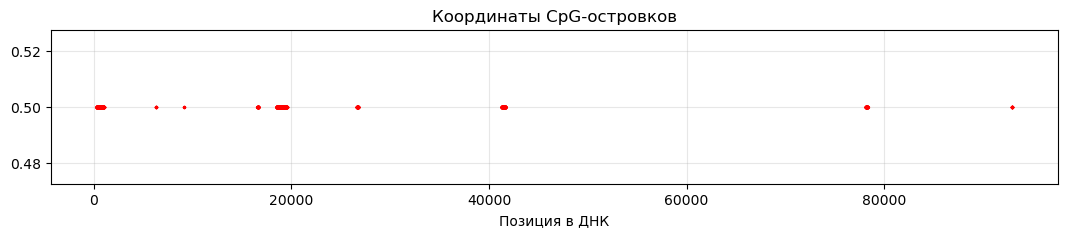

In [307]:
plt.figure(figsize=(13,2))
plt.scatter(CpG_coords, [0.5]*len(CpG_coords), color='red', s=2, label='CpG starts', zorder=5)
plt.xlabel('Позиция в ДНК')
plt.title('Координаты CpG-островков')
plt.grid(True, alpha=0.3)
plt.show()

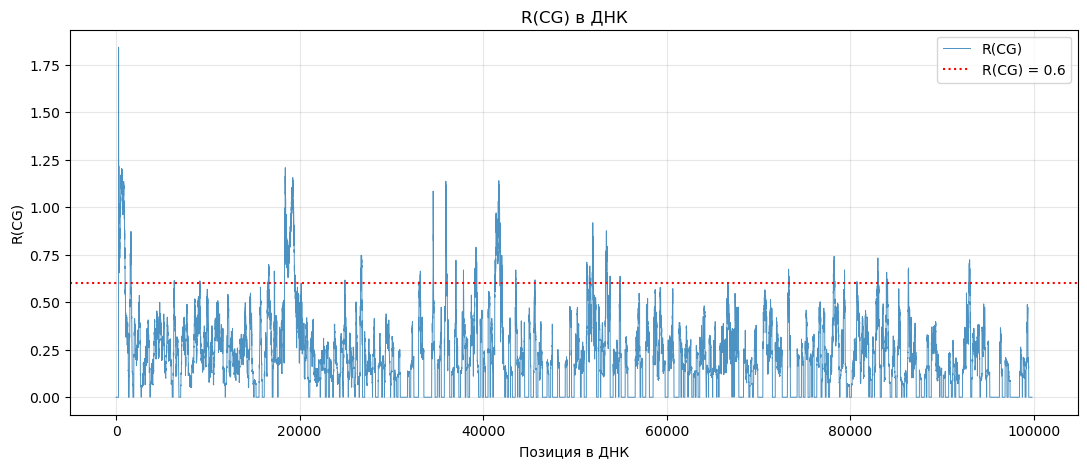

In [313]:
plt.figure(figsize=(13, 5))
plt.plot(range(len(seq)-window_size+1), R_CGs, alpha=0.8, linewidth=0.7, label='R(CG)')
plt.axhline(y=0.6, color='red', linestyle=':', label='R(CG) = 0.6')
plt.xlabel('Позиция в ДНК')
plt.ylabel('R(CG)')
plt.title('R(CG) в ДНК')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

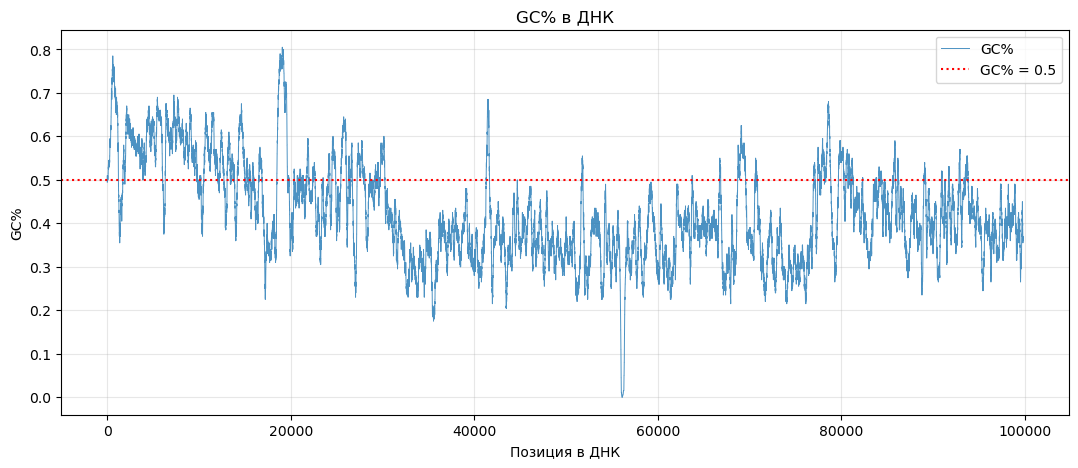

In [315]:
plt.figure(figsize=(13, 5))
plt.plot(range(len(seq)-window_size+1), GC_pers, alpha=0.8, linewidth=0.7, label='GC%')
plt.axhline(y=0.5, color='red', linestyle=':', label='GC% = 0.5')
plt.xlabel('Позиция в ДНК')
plt.ylabel('GC%')
plt.title('GC% в ДНК')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()